<img src="../Decorative-Elements/Section-03/Section-03-04/Section-03-04-08.png">
<p style="display: flex; justify-content: space-between;">
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-07.ipynb" target="_blank">Previous</a>
  <a href="../04-Understanding-Integrators/01-WHFast-Integrator.ipynb" target="_blank">Next</a>
</p>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Planet: Neptune

# Average distance from Sun: 30.07 AU
# Orbital period around Sun: 164.8 Earth years
# Orbital period in days: 60,190 days
# Total number of confirmed moons: 14

# 164.8 Earth years is equivalent to approximately 60,190 days.
# Neptune takes the longest time among the eight planets to complete one revolution around the Sun.

# Rotation period (one spin on its axis): 16.1 hours
# Neptune rotates rapidly compared to its extremely long orbital period.

# Neptune has a faint ring system.
# It is the farthest known major planet in the Solar System.

# Major Moons:

# Triton
# Orbital period: 5.88 days
# Largest moon of Neptune
# Orbits in retrograde direction

# Nereid
# Orbital period: 360.1 days
# Has a highly eccentric orbit

# Proteus
# Orbital period: 1.12 days

# Proteus revolves fastest among the listed major moons.
# Nereid has the longest orbital period among them.

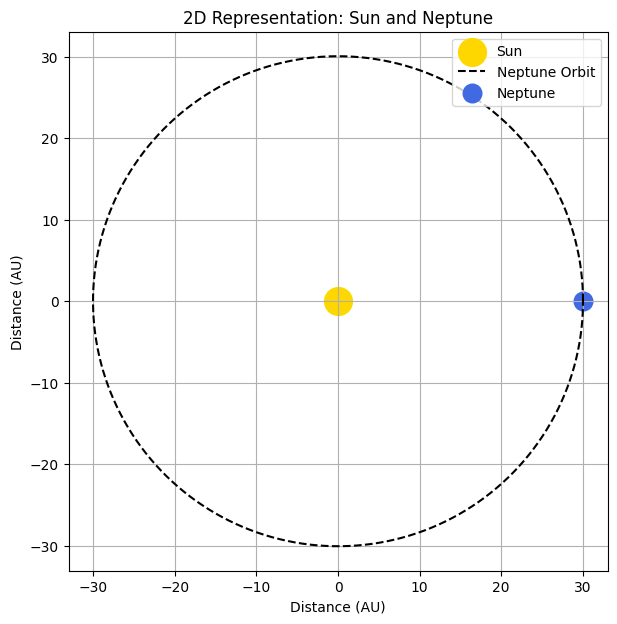

In [3]:
neptune_radius = 30.05  # AU

theta = np.linspace(0, 2*np.pi, 400)

x_orbit = neptune_radius * np.cos(theta)
y_orbit = neptune_radius * np.sin(theta)

plt.figure(figsize=(7,7))

# Sun
plt.scatter(0, 0, s=400, color='gold', label='Sun')

# Neptune orbit
plt.plot(x_orbit, y_orbit, linestyle='--', color='black', label='Neptune Orbit')

# Neptune position
plt.scatter(neptune_radius, 0, s=180, color='royalblue', label='Neptune')

plt.gca().set_aspect('equal', 'box')
plt.title("2D Representation: Sun and Neptune")
plt.xlabel("Distance (AU)")
plt.ylabel("Distance (AU)")
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

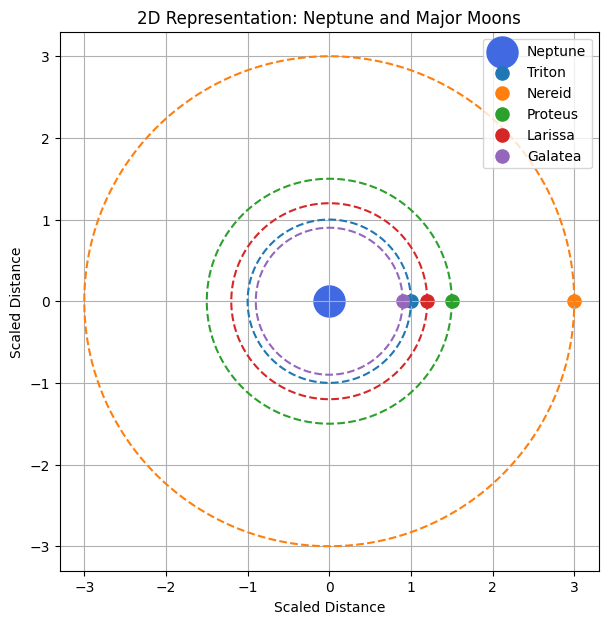

In [4]:
# Scaled orbital radii for Neptune moons (visual purpose)
moon_radii = {
    "Triton": 1.0,
    "Nereid": 3.0,
    "Proteus": 1.5,
    "Larissa": 1.2,
    "Galatea": 0.9
}

theta = np.linspace(0, 2*np.pi, 400)

plt.figure(figsize=(7,7))

# Neptune at center
plt.scatter(0, 0, s=500, color='royalblue', label='Neptune')

# Draw orbits and moon positions
for moon, radius in moon_radii.items():
    x_orbit = radius * np.cos(theta)
    y_orbit = radius * np.sin(theta)

    plt.plot(x_orbit, y_orbit, linestyle='--')
    plt.scatter(radius, 0, s=90, label=moon)

plt.gca().set_aspect('equal', 'box')
plt.title("2D Representation: Neptune and Major Moons")
plt.xlabel("Scaled Distance")
plt.ylabel("Scaled Distance")
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

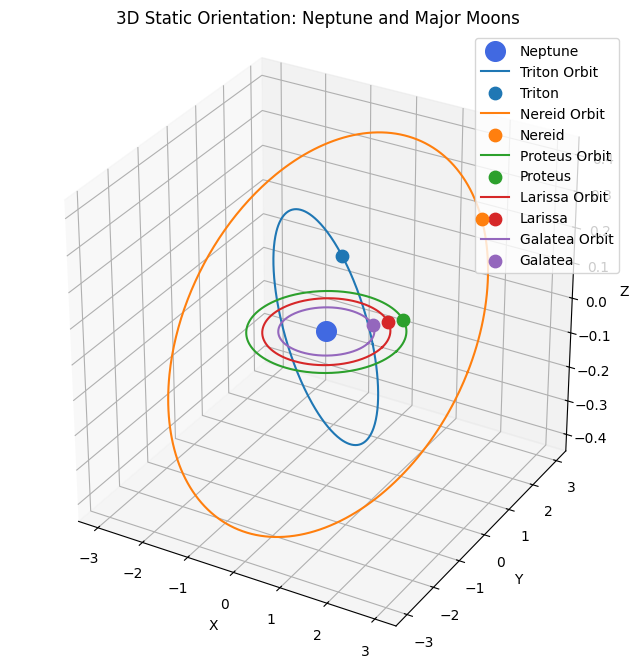

In [5]:
# Scaled orbital radii and inclinations (visual purpose)
moon_data = {
    "Triton": (1.0, 156.9),   # retrograde large inclination
    "Nereid": (3.0, 7.0),
    "Proteus": (1.5, 0.1),
    "Larissa": (1.2, 0.2),
    "Galatea": (0.9, 0.0)
}

theta = np.linspace(0, 2*np.pi, 400)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Neptune at origin
ax.scatter(0, 0, 0, s=200, color='royalblue', label='Neptune')

for moon, (radius, inclination_deg) in moon_data.items():
    
    inc = np.radians(inclination_deg)
    
    # Base circular orbit in x-y plane
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    z = np.zeros_like(theta)
    
    # Rotate orbit around x-axis to create inclination
    y_rot = y * np.cos(inc)
    z_rot = y * np.sin(inc)
    
    # Plot orbit
    ax.plot(x, y_rot, z_rot, label=f'{moon} Orbit')
    
    # Plot moon at one position (45° for visibility)
    angle = np.pi / 4
    moon_x = radius * np.cos(angle)
    moon_y = radius * np.sin(angle) * np.cos(inc)
    moon_z = radius * np.sin(angle) * np.sin(inc)
    
    ax.scatter(moon_x, moon_y, moon_z, s=80, label=moon)

ax.set_title("3D Static Orientation: Neptune and Major Moons")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.legend(loc='upper right')
ax.set_box_aspect([1,1,1])

plt.show()

In [6]:
# Moon data: (scaled radius, inclination in degrees)
moon_data = {
    "Triton": (1.0, 156.9),   # retrograde, large inclination
    "Nereid": (3.0, 7.0),
    "Proteus": (1.5, 0.1),
    "Larissa": (1.2, 0.2),
    "Galatea": (0.9, 0.0)
}

theta = np.linspace(0, 2*np.pi, 400)

fig = go.Figure()

# Neptune at origin
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=20, color='royalblue'),
    name='Neptune'
))

for moon, (radius, inc_deg) in moon_data.items():
    inc = np.radians(inc_deg)
    
    # Base circular orbit in xy-plane
    x = radius * np.cos(theta)
    y_base = radius * np.sin(theta)
    z_base = np.zeros_like(theta)
    
    # Incline orbit about x-axis
    y_rot = y_base * np.cos(inc)
    z_rot = y_base * np.sin(inc)
    
    # Orbit line
    fig.add_trace(go.Scatter3d(
        x=x, y=y_rot, z=z_rot,
        mode='lines',
        line=dict(width=2),
        name=f"{moon} Orbit"
    ))
    
    # Moon position at 45° along orbit
    angle = np.pi / 4
    moon_x = radius * np.cos(angle)
    moon_y = radius * np.sin(angle) * np.cos(inc)
    moon_z = radius * np.sin(angle) * np.sin(inc)
    
    fig.add_trace(go.Scatter3d(
        x=[moon_x], y=[moon_y], z=[moon_z],
        mode='markers',
        marker=dict(size=6),
        name=moon
    ))

# Layout
fig.update_layout(
    title="3D Static Orientation: Neptune and Major Moons",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data'
    ),
    width=800,
    height=800,
    showlegend=True
)

fig.show()

# Output is not visible in github webpage, refer to Folder/Output-Plotly

<p style="display: flex; justify-content: space-between;">
  <a href="../03-Solar-System/04-Moon-Orbits-of-Each-Planet-07.ipynb" target="_blank">Previous</a>
  <a href="../04-Understanding-Integrators/01-WHFast-Integrator.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-03-04/Section-03-04-h.gif">